In [ ]:
pip install tensorflow numpy matplotlib pandas scikit-learn


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from PIL import Image
import seaborn as sns




In [ ]:

os.listdir('/content/drive/MyDrive/dataset/bengali_digits/9')

['1_B.baria_22_3_00039.jpg',
 '1_B.baria_25_3_00084.jpg',
 '1_BAG_12_1_337.jpg',
 '1_B.BARIA_12_1_87.jpg',
 '1_BAR_11_1_347.jpg',
 '1_B.BARIA_11_1_320.jpg',
 '1_B.BARIA_1_1_328.jpg',
 '1_BAR_11_1_348.jpg',
 '1_BAR_11_1_353.jpg',
 '1_BAR_11_1_342.jpg',
 '1_B.BARIA_12_1_325.jpg',
 '1_BAR_11_1_346.jpg',
 '1_B.BARIA_13_1_88.jpg',
 '1_B.BARIA_11_1_322.jpg',
 '1_22_Farid_3_318.jpg',
 '1_B.BARIA_13_1_326.jpg',
 '1_BAG_11_1_333.jpg',
 '1_B.BARI_13_1_330.jpg',
 '1_BAG_11_1_334.jpg',
 '1_BAR_11_1_350.jpg',
 '1_BAG_11_1_332.jpg',
 '1_B.BARIA_11_1_321.jpg',
 '1_BAR_10_1_340.jpg',
 '1_BARG_11_1_339.jpg',
 '1_14_BOG_1_317.jpg',
 '1_BAG_11_1_336.jpg',
 '1_BAR_11_1_349.jpg',
 '1_B.BARIA_11_1_319.jpg',
 '1_BAG_12_1_338.jpg',
 '1_B.BARIA_22_3_329.jpg',
 '1_BAR_11_1_344.jpg',
 '1_B.BARIA_11_1_324.jpg',
 '1_BAR_11_1_343.jpg',
 '1_BAR_11_1_351.jpg',
 '1_B.BARIA_14_1_327.jpg',
 '1_BAR_11_1_341.jpg',
 '1_BAR_11_1_345.jpg',
 '1_B.BARIA_11_1_323.jpg',
 '1_BAR_11_1_352.jpg',
 '1_B.BARI_14_331.jpg',
 '1_MANIK_14

In [ ]:

dataset_path = '/content/drive/MyDrive/dataset/bengali_digits'

In [ ]:

IMG_SIZE = 28
classes = sorted(os.listdir(dataset_path))

data = []
labels = []

In [ ]:
for label, folder in enumerate(classes):
  folder_path = os.path.join(dataset_path, folder)
  for image in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image)
    image = Image.open(image_path).convert('L')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    image = np.array(image)
    data.append(image)
    labels.append(label)

In [ ]:

data = np.array(data).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
labels = np.array(labels)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11904, 28, 28, 1)
y_train shape: (11904, 10)
X_test shape: (2977, 28, 28, 1)
y_test shape: (2977, 10)


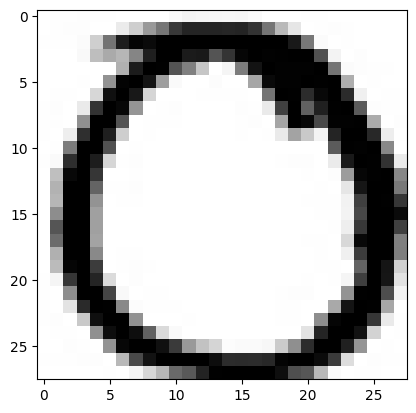

In [ ]:
plt.imshow(X_train[5], cmap='gray')

In [ ]:
#CNN Model

model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])


In [ ]:
#Compiling model

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Traning the model

history = model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=32)

Epoch 1/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.6594 - loss: 1.0716 - val_accuracy: 0.9043 - val_loss: 0.3035
Epoch 2/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9235 - loss: 0.2453 - val_accuracy: 0.9261 - val_loss: 0.2677
Epoch 3/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.9469 - loss: 0.1646 - val_accuracy: 0.9379 - val_loss: 0.2145
Epoch 4/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.9597 - loss: 0.1200 - val_accuracy: 0.9404 - val_loss: 0.2169
Epoch 5/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9706 - loss: 0.0885 - val_accuracy: 0.9597 - val_loss: 0.1584
Epoch 6/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9821 - loss: 0.0602 - val_accuracy: 0.9547 - val_loss: 0.1899
Epoch 7/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9884 - loss: 0.0413 - val_accuracy: 0.9563 - val_loss: 0.2008
Epoch 8/10
335/335 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.9900 - loss: 0.0296 - 

In [ ]:
#Evaluating the model

test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9555 - loss: 0.1635
Test accuracy: 0.9583473205566406


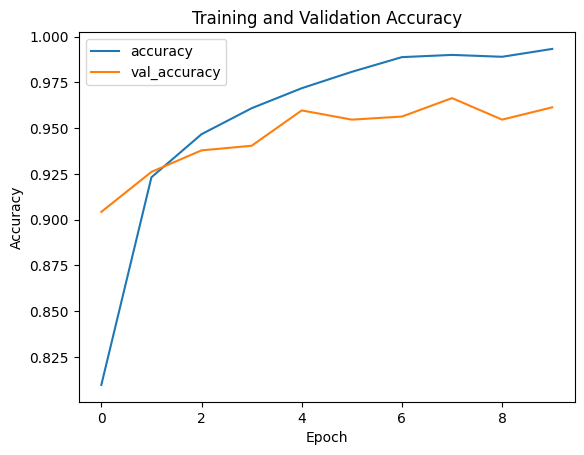

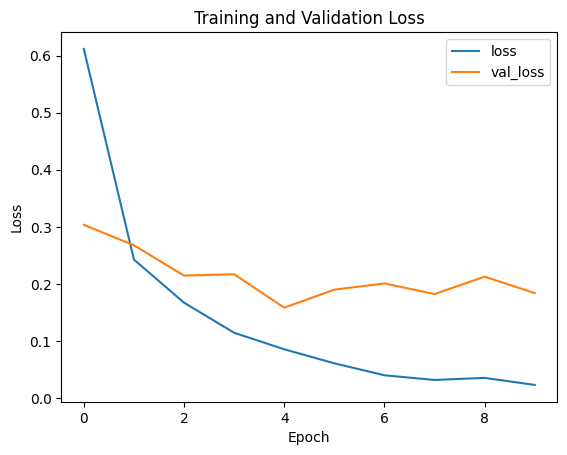

In [ ]:
#Visualize Plot training

#plot accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

#plot loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Digit: 9


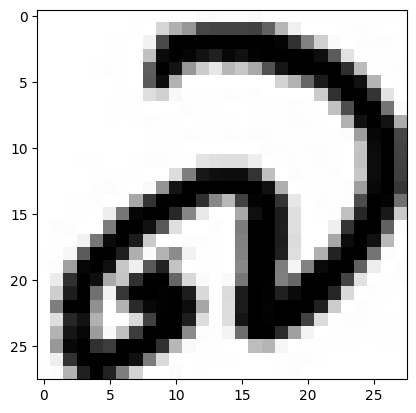

In [ ]:
#Load new image

image = Image.open('/content/drive/MyDrive/dataset/bengali_digits/9/1_CHAD_11_1_499.jpg').convert('L').resize((28, 28))
image = np.array(image).reshape(1, 28, 28, 1) / 255.0

plt.imshow(X_test[35], cmap='gray')

#Predict

prediction = np.argmax(model.predict(image))
print(f"Predicted Digit: {prediction}")